In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Walk up from cwd until we find pyproject.toml (Jupyter sets cwd to the notebook
# folder, so the repo root is not cwd).
project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import analysis
from src import label_switching as ls

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 5)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Load Posterior Draws ──────────
# This notebook lives in <run>/ ; all artifacts live in <run>/results/.

def _resolve_run_dir():
    # VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        return pathlib.Path(nb).resolve().parent
    return pathlib.Path.cwd()

RUN_DIR     = _resolve_run_dir()
RESULTS_DIR = RUN_DIR / "results"
meta_path   = RESULTS_DIR / "meta.json"

if not meta_path.exists():
    raise FileNotFoundError(
        f"meta.json not found in:\n  {RESULTS_DIR}\n\n"
        f"This notebook must live in a run folder with artifacts in a results/ subfolder.\n"
        f"If you are in VS Code and this fails, set\n"
        f"  \"jupyter.notebookFileRoot\": \"${{fileDirname}}\"\n"
        f"so the working directory is the notebook's own folder, then restart the kernel."
    )

with open(meta_path) as f:
    meta = json.load(f)

SCENARIO_NAME = meta["scenario"]
K_MODEL       = int(meta["k_model"])
K_TRUE        = int(meta["k_true"])
SAMPLER       = meta["sampler"]
CHAINS        = int(meta["chains"])

with open(RESULTS_DIR / "posterior_raw.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(f"Run folder : {RUN_DIR}")
print(f"Scenario   : {SCENARIO_NAME}   sampler: {SAMPLER}   chains: {CHAINS}")
print(f"K_MODEL    : {K_MODEL}   K_TRUE : {K_TRUE}")
print("\nPosterior arrays:")
for key, val in posterior_samples.items():
    print(f"   {key:<28} {np.asarray(val).shape}")

Run folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\3_comp\HMC\3comp_equal_K5_seed42
Scenario   : 3comp_equal   sampler: hmc   chains: 1
K_MODEL    : 5   K_TRUE : 3

Posterior arrays:
   Delta                        (1, 10000, 2, 4)
   beta_i                       (1, 10000, 300, 4)
   mu_k                         (1, 10000, 5, 4)
   pvec_latent                  (1, 10000, 4)
   sigma_inv_chol_k_latent      (1, 10000, 5, 10)


In [3]:
# ── Cell 3 : Ground Truth & Demographics ──────────
# Z is needed to reconstruct allocations via the household-specific mean
# mu_k + Z_i @ Delta (Rossi Eq. 5.5.19).
data_path = project_root / "data" / "simulated" / "mixture" / f"{SCENARIO_NAME}.json"
with open(data_path) as f:
    raw_data = json.load(f)

t_pvec = np.array(raw_data["TRUE_PVEC"]) if raw_data.get("TRUE_PVEC") is not None else None
Z      = np.array(raw_data["Z"]) if raw_data.get("Z") is not None else None

print(f"Ground truth from {data_path.name}")
if t_pvec is not None:
    print(f"TRUE_PVEC : {t_pvec.round(4)}")

Ground truth from 3comp_equal.json
TRUE_PVEC : [0.3333 0.3333 0.3333]


In [4]:
# ── Cell 4 : Invariant-Convergence Gate ──────────
# Relabeling removes PERMUTATION ambiguity only - it cannot fix genuine
# multimodality. So FIRST assess convergence on the label-INVARIANT functionals
# (mixture mean E[u], sorted pvec, tr Cov[u]). A high sorted-pvec R-hat means the
# weight posterior is genuinely multimodal (the established K=5 finding), NOT a
# label artifact, and no relabeling can fix that.
gate = analysis.invariant_convergence_summary(posterior_samples, include_cov=True)
display(gate.round(4))

arviz - WARNING - Shape validation failed: input_shape: (1, 10000), minimum_shape: (chains=2, draws=4)


,rhat,ess
quantity,,
E[u]_0,NaN,4.1229
E[u]_1,NaN,118.8617
E[u]_2,NaN,56.7928
E[u]_3,NaN,84.7610
pvec_sorted_0,NaN,41.2057
pvec_sorted_1,NaN,29.0992
pvec_sorted_2,NaN,57.6950
pvec_sorted_3,NaN,98.8779
pvec_sorted_4,NaN,1208.3978


In [5]:
# ── Cell 5 : ECR Relabeling of pvec ──────────
# ECR iterative version 1 (Papastamoulis 2016, Algorithm 5). Allocations are
# reconstructed from mu_k + Z@Delta, Sigma_k, pvec and beta_i (Liesel
# marginalizes them), so the same method serves NUTS / HMC / bayesm.
# ONLY pvec is post-processed - everything else stays label-invariant.
pvec_before = np.asarray(analysis._recover_pvec(posterior_samples))   # (C,S,K)
pvec_after, report = ls.relabel_pvec(posterior_samples, K=K_MODEL, Z=Z, K_true=K_TRUE)
verdict = ls.classify_outcome(report, gate)

print(f"ECR converged   : {report['converged']}  (in {report['n_iter']} sweeps)")
print(f"switching rate  : {report['switching_rate']:.3f}  (fraction of draws relabeled)")
print(f"invariant R-hat : pvec_sorted={verdict['invariant_pvec_sorted_rhat']:.3f}  "
      f"(gate_passed={verdict['gate_passed']})")
print(f"\nVERDICT : {verdict['verdict']}")

ECR converged   : True  (in 2 sweeps)
switching rate  : 0.266  (fraction of draws relabeled)
invariant R-hat : pvec_sorted=nan  (gate_passed=False)

VERDICT : PERMUTATION-FIXED (label switching was present and has been aligned by ECR)


Mean pvec per slot (before = label-switched -> smeared; after = ordered):


,mean_pvec_before,mean_pvec_after
slot 0,0.306,0.370
slot 1,0.007,0.311
slot 2,0.022,0.295
slot 3,0.370,0.016
slot 4,0.295,0.008


Per-slot R-hat / ESS - BEFORE:


,stage,slot,live,rhat,ess
0,before,3,True,NaN,1231.751
1,before,0,True,NaN,42.463
2,before,4,True,NaN,151.230
3,before,2,False,NaN,29.673
4,before,1,False,NaN,54.881


Per-slot R-hat / ESS - AFTER:


,stage,slot,live,rhat,ess
0,after,0,True,NaN,1231.751
1,after,1,True,NaN,53.050
2,after,2,True,NaN,150.915
3,after,3,False,NaN,34.552
4,after,4,False,NaN,43.968


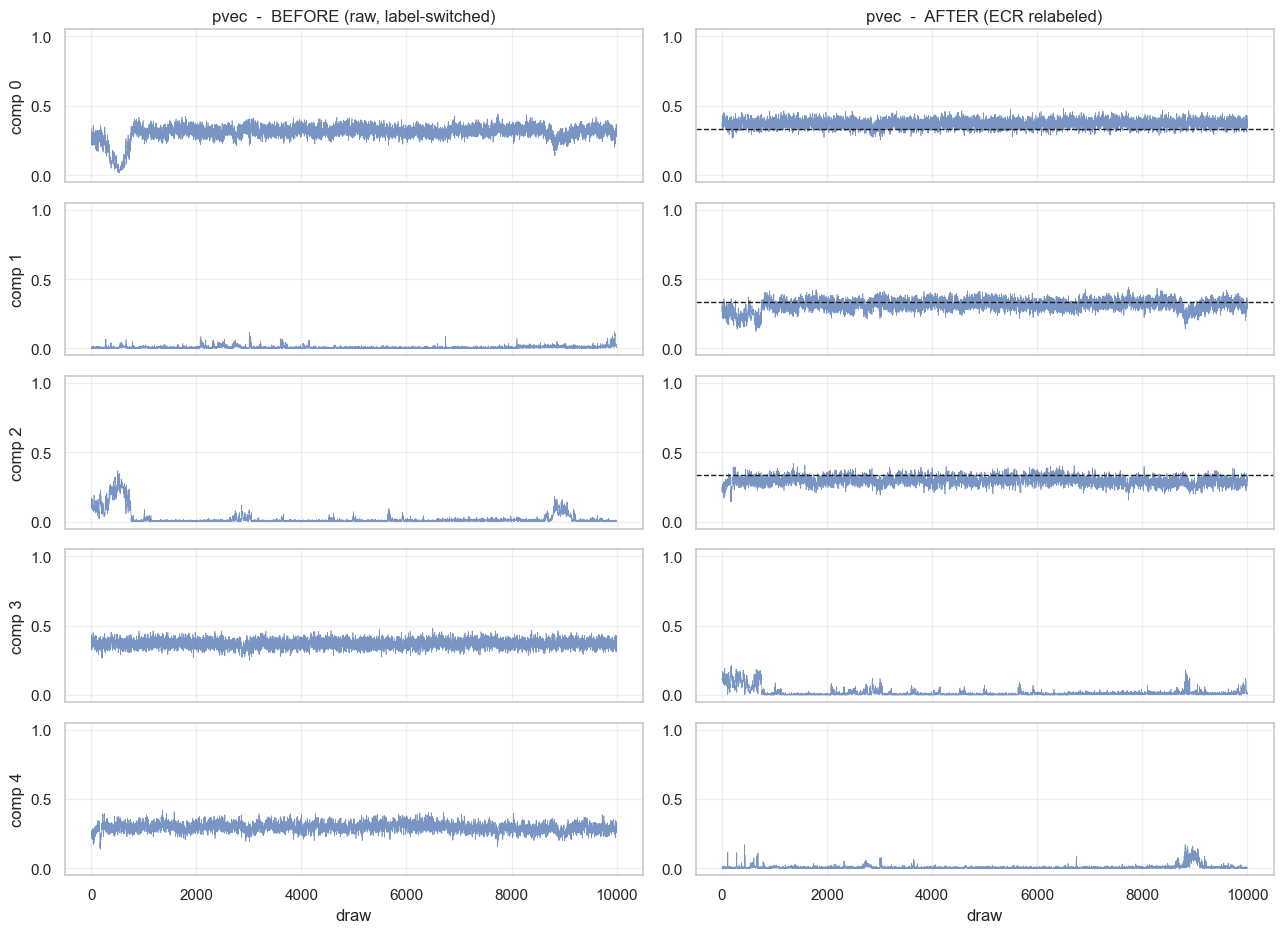

In [6]:
# ── Cell 6 : pvec - Before / After (all slots) ──────────
mb = pvec_before.reshape(-1, K_MODEL).mean(0)
ma = pvec_after.reshape(-1, K_MODEL).mean(0)
print("Mean pvec per slot (before = label-switched -> smeared; after = ordered):")
display(pd.DataFrame({"mean_pvec_before": mb.round(3), "mean_pvec_after": ma.round(3)},
                     index=[f"slot {k}" for k in range(K_MODEL)]))

# For purely within-chain switching R-hat can already be ~1 - then ESS recovery
# is the signal.
print("Per-slot R-hat / ESS - BEFORE:")
display(ls.pvec_convergence_table(pvec_before, K_MODEL, K_TRUE, label="before").round(3))
print("Per-slot R-hat / ESS - AFTER:")
display(ls.pvec_convergence_table(pvec_after, K_MODEL, K_TRUE, label="after").round(3))

# y-axis fixed to (-0.05, 1.05) to match the analysis notebook's pvec traces.
ls.plot_before_after_traces(pvec_before, pvec_after, K_MODEL, title="pvec",
                            true_vals=t_pvec, ylim=(-0.05, 1.05))

In [7]:
# ── Cell 7 : Guard, Recovery & Persist ──────────
ok = ls.invariance_guard(pvec_before, pvec_after)
print(f"Invariance guard (per-draw sorted pvec identical): {ok}")
print("  (no-corruption check only - it passes for ANY per-draw permutation, so")
print("   it does not by itself certify the relabeling is correct.)\n")

if t_pvec is not None:
    live = report["live_slots"]
    rel = pvec_after.reshape(-1, K_MODEL).mean(0)[live]
    print("Live-slot mean pvec vs truth (both weight-ordered, rank-to-rank):")
    display(pd.DataFrame({"pvec_post": rel.round(3),
                          "pvec_true": np.sort(t_pvec)[::-1].round(3)},
                         index=[f"slot {k}" for k in live]))

print("\nCAVEATS (per project methodology):")
print(" - Only pvec is relabeled; all other inference uses label-invariant")
print("   functionals (marginal density, mixture moments).")
print(" - ECR aligns permutations WITHIN a mode; if the invariant sorted-pvec")
print("   R-hat (Cell 4) is high, the weight posterior is multimodal - not a")
print("   label artifact - and per-slot summaries stay illustrative.")
print(" - Empty components (K_MODEL > K_TRUE) are unidentified.")

# Persist additively (never touches posterior_raw.pkl).
with open(RESULTS_DIR / "relabeled_pvec.pkl", "wb") as f:
    pickle.dump({"pvec": np.asarray(pvec_after),
                 "permutations": np.asarray(report["permutations"])}, f)
print(f"\nSaved relabeled pvec -> {(RESULTS_DIR / 'relabeled_pvec.pkl')}")

Invariance guard (per-draw sorted pvec identical): True
  (no-corruption check only - it passes for ANY per-draw permutation, so
   it does not by itself certify the relabeling is correct.)

Live-slot mean pvec vs truth (both weight-ordered, rank-to-rank):


,pvec_post,pvec_true
slot 0,0.370,0.333
slot 1,0.311,0.333
slot 2,0.295,0.333



CAVEATS (per project methodology):
 - Only pvec is relabeled; all other inference uses label-invariant
   functionals (marginal density, mixture moments).
 - ECR aligns permutations WITHIN a mode; if the invariant sorted-pvec
   R-hat (Cell 4) is high, the weight posterior is multimodal - not a
   label artifact - and per-slot summaries stay illustrative.
 - Empty components (K_MODEL > K_TRUE) are unidentified.

Saved relabeled pvec -> C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\3_comp\HMC\3comp_equal_K5_seed42\results\relabeled_pvec.pkl
